# 2D 精细网格 (f2h × h2f)：交互面与源-汇平衡

`grid_2d_fine_v1`：把双轴都铺满——`Farmer.convert_prob.to_hunter` (f2h，漏/汇) 与 `Hunter.convert_prob.to_farmer` (h2f，源)，11 × 11 = 121 组合 × 5 repeats × 500 步。前两次稀疏实验只有 "+" 字形 9 个交叉，这次填满整个交互面。

## 此 notebook 回答四件事

1. **整个交互面长什么样**：热力图 + 等值线，看 farmer 数末态如何随 (f2h, h2f) 变化
2. **是不是可分离**：在 log 空间拟合可加模型 `log N ≈ a(f2h) + b(h2f) + c`，残差就是真实交互项
3. **源-汇平衡线**：找出 farmer 数等于某基线（如 `(0,0)` 的一半）的等值线，看 h2f 对 f2h 的「补偿能力」是线性还是饱和
4. **边缘切片与前两次实验对得上吗**：与 `h2f_fine_v1` 在 3×11=33 个点重合，做交叉验证

## 设计

- f2h ∈ {0, 0.002, ..., 0.020}（11 值，步长 0.002）
- h2f ∈ {0, 0.015, ..., 0.150}（11 值，步长 0.015）
- 5 repeats 每组，末段 50 步取均值
- 与 `h2f_fine_v1` (3 f2h × 31 h2f) 的 3×11=33 个网格点重合
- 与 `threshold_v1` (11 f2h × 3 h2f, h2f∈{0,0.05,0.10}) 仅 h2f=0 一列重合（h2f 网格不同）


In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)

# CJK 字体（顺序：sns.set_theme 之后追加）
try:
    from matplotkit import config_font

    config_font("SunTimes")
except Exception:
    pass
import matplotlib as _mpl

_cjk = ["PingFang HK", "Hiragino Sans GB", "Songti SC", "STHeiti", "Heiti TC"]
_mpl.rcParams["font.sans-serif"] = _cjk + list(_mpl.rcParams["font.sans-serif"])
_mpl.rcParams["axes.unicode_minus"] = False

REPO = Path.cwd()
if REPO.name == "reports":
    REPO = REPO.parent
SWEEP_2D = REPO / "out/south_china_evolution/grid_2d_fine_v1"
SWEEP_H2F = REPO / "out/south_china_evolution/grid_h2f_fine_v1"
REPORTS = REPO / "reports"

DIR_RE = re.compile(r"^idx(?P<idx>\d+)_f2h(?P<f2h>[\d.]+)_h2f(?P<h2f>[\d.]+)$")
TRACK_RE = re.compile(r"^(?P<run_id>\d+)_tracking\.csv$")

METRIC_COLS = [
    "num_farmers_n",
    "num_hunters_n",
    "num_rice_n",
    "len_farmers_n",
    "len_hunters_n",
    "len_rice_n",
]


def load_grid(root, cols=METRIC_COLS):
    rows = []
    for d in sorted(root.iterdir()):
        m = DIR_RE.match(d.name)
        if not m:
            continue
        idx = int(m["idx"])
        f2h = float(m["f2h"])
        h2f = float(m["h2f"])
        for f in sorted(d.iterdir()):
            tm = TRACK_RE.match(f.name)
            if not tm:
                continue
            run_id = int(tm["run_id"])
            df = pd.read_csv(f, usecols=lambda c: c in ("step", *cols))
            df["run_id"] = run_id
            df["f2h"] = f2h
            df["h2f"] = h2f
            df["idx"] = idx
            rows.append(df)
    return pd.concat(rows, ignore_index=True)


grid = load_grid(SWEEP_2D)
print("rows:", len(grid))
print("combos:", grid[["f2h", "h2f"]].drop_duplicates().shape[0])
print("f2h:", sorted(grid["f2h"].unique()))
print("h2f:", sorted(grid["h2f"].unique()))
print("steps:", grid["step"].min(), "→", grid["step"].max())
print("run_ids per combo:", grid.groupby(["f2h", "h2f"])["run_id"].nunique().unique())

rows: 303105
combos: 121
f2h: [np.float64(0.0), np.float64(0.002), np.float64(0.004), np.float64(0.006), np.float64(0.008), np.float64(0.01), np.float64(0.012), np.float64(0.014), np.float64(0.016), np.float64(0.018), np.float64(0.02)]
h2f: [np.float64(0.0), np.float64(0.015), np.float64(0.03), np.float64(0.045), np.float64(0.06), np.float64(0.075), np.float64(0.09), np.float64(0.105), np.float64(0.12), np.float64(0.135), np.float64(0.15)]
steps: 0 → 500
run_ids per combo: [5]


## 末段 50 步聚合 → 11 × 11 透视

每组 (f2h, h2f) 在末段 50 步内取均值，再在 5 repeats 上算 mean / std / CV。

In [2]:
tail = grid[grid["step"] >= grid["step"].max() - 50]
per_repeat = tail.groupby(["f2h", "h2f", "run_id"], as_index=False)[METRIC_COLS].mean()

piv_mean = (
    per_repeat.pivot_table(
        index="h2f", columns="f2h", values="num_farmers_n", aggfunc="mean"
    )
    .sort_index()
    .sort_index(axis=1)
)
piv_std = (
    per_repeat.pivot_table(
        index="h2f", columns="f2h", values="num_farmers_n", aggfunc="std"
    )
    .sort_index()
    .sort_index(axis=1)
)
piv_cv = (piv_std / piv_mean).round(3)

print("透视形状:", piv_mean.shape, "（应为 11 × 11）")
print(
    "最大 CV:",
    float(piv_cv.values.max()),
    "  中位 CV:",
    float(np.median(piv_cv.values)),
)
display(piv_mean.round(0))

透视形状: (11, 11) （应为 11 × 11）
最大 CV: 0.076   中位 CV: 0.018


f2h,0.000,0.002,0.004,0.006,0.008,0.010,0.012,0.014,0.016,0.018,0.020
h2f,,,,,,,,,,,
0.000,273841.0,211076.0,147560.0,100412.0,75692.0,58328.0,47528.0,39028.0,34411.0,30401.0,26836.0
0.015,333213.0,272224.0,194176.0,131128.0,95334.0,76937.0,66219.0,58698.0,53106.0,48297.0,42746.0
0.030,355400.0,292455.0,223409.0,154356.0,109508.0,86469.0,73913.0,66787.0,60565.0,56873.0,51874.0
0.045,372006.0,308760.0,242468.0,172935.0,120096.0,94633.0,81576.0,73717.0,66418.0,62520.0,58694.0
0.060,382724.0,324337.0,254749.0,184731.0,132470.0,103194.0,86541.0,78236.0,71675.0,66127.0,62193.0
0.075,390690.0,339478.0,265623.0,192860.0,142324.0,109322.0,92474.0,82784.0,75758.0,70020.0,66518.0
0.090,404172.0,350038.0,277294.0,209258.0,148485.0,117606.0,97274.0,87390.0,80033.0,73597.0,70156.0
0.105,407288.0,347716.0,282517.0,218893.0,163262.0,124816.0,105662.0,90503.0,83321.0,78164.0,73428.0
0.120,414950.0,358894.0,292471.0,227568.0,168743.0,132228.0,111425.0,96370.0,86702.0,80773.0,75407.0


## 图 1：交互面热力图 + 等值线

- 颜色：末态 `num_farmers_n`（log 色阶——人口跨多个量级）
- 等值线：在线性空间标几条人口水平线（10⁵、2×10⁵、3×10⁵），看 "等 farmer 数" 在 (f2h, h2f) 上的轨迹

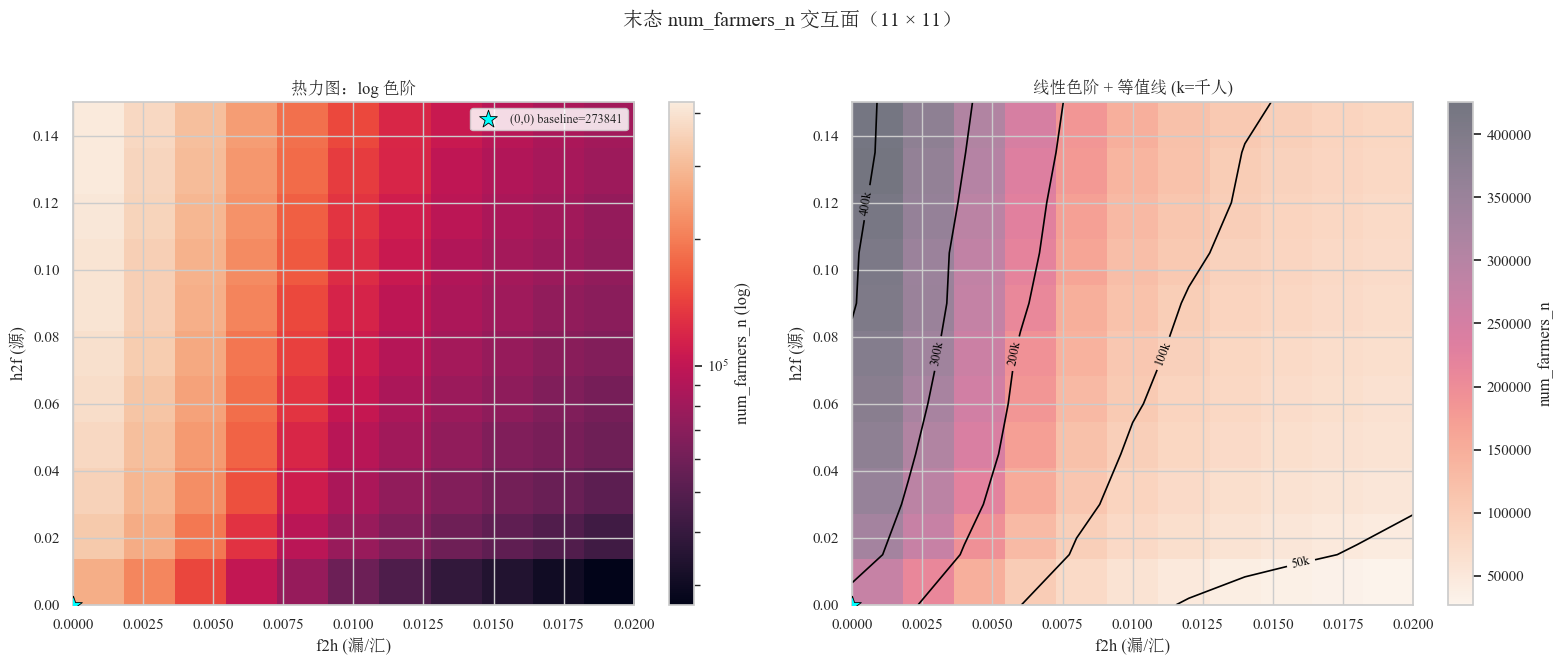

saved: /Users/songshgeo/Documents/CodeBase/Scholar/SC-20230710-SCE/reports/convert_prob_2d_heatmap.png


In [3]:
from matplotlib.colors import LogNorm

f2h_vals = piv_mean.columns.values
h2f_vals = piv_mean.index.values
Z = piv_mean.values.astype(float)
Z_safe = np.where(Z <= 0, 1.0, Z)
F2H_M, H2F_M = np.meshgrid(f2h_vals, h2f_vals)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# 左：log 色阶热力图
im = axes[0].imshow(
    Z_safe,
    origin="lower",
    aspect="auto",
    cmap="rocket",
    norm=LogNorm(vmin=max(1.0, Z_safe.min()), vmax=Z_safe.max()),
    extent=(f2h_vals.min(), f2h_vals.max(), h2f_vals.min(), h2f_vals.max()),
)
axes[0].scatter(
    [0],
    [0],
    marker="*",
    s=180,
    color="cyan",
    edgecolor="black",
    linewidth=0.6,
    zorder=5,
    label=f"(0,0) baseline={Z_safe[0,0]:.0f}",
)
axes[0].set_xlabel("f2h (漏/汇)")
axes[0].set_ylabel("h2f (源)")
axes[0].set_title("热力图：log 色阶")
fig.colorbar(im, ax=axes[0], label="num_farmers_n (log)")
axes[0].legend(loc="upper right", fontsize=9, framealpha=0.85)

# 右：线性色阶 + 等值线（独立 axes，避免 LogNorm 串扰）
levels = sorted([5e4, 1e5, 2e5, 3e5, 4e5])
im2 = axes[1].imshow(
    Z_safe,
    origin="lower",
    aspect="auto",
    cmap="rocket_r",
    vmin=Z_safe.min(),
    vmax=Z_safe.max(),
    extent=(f2h_vals.min(), f2h_vals.max(), h2f_vals.min(), h2f_vals.max()),
    alpha=0.55,
)
cs = axes[1].contour(
    F2H_M, H2F_M, Z_safe, levels=levels, colors="black", linewidths=1.2
)
axes[1].clabel(cs, fmt=lambda v: f"{int(v/1000)}k", fontsize=9, inline=True)
axes[1].scatter(
    [0],
    [0],
    marker="*",
    s=180,
    color="cyan",
    edgecolor="black",
    linewidth=0.6,
    zorder=5,
)
axes[1].set_xlabel("f2h (漏/汇)")
axes[1].set_ylabel("h2f (源)")
axes[1].set_title("线性色阶 + 等值线 (k=千人)")
fig.colorbar(im2, ax=axes[1], label="num_farmers_n")

fig.suptitle("末态 num_farmers_n 交互面（11 × 11）", y=1.02)
fig.tight_layout()
fig_path = REPORTS / "convert_prob_2d_heatmap.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("saved:", fig_path)

## 图 2：边缘切片

- 左：固定每个 h2f 当横轴，看 f2h 怎么把人口拉下去（11 条 h2f 曲线）
- 右：转置——每个 f2h 当横轴，看 h2f 怎么把人口抬起来（11 条 f2h 曲线）

调色板用 viridis（色阶顺序对应 h2f 或 f2h 由小到大）。y 轴 log。

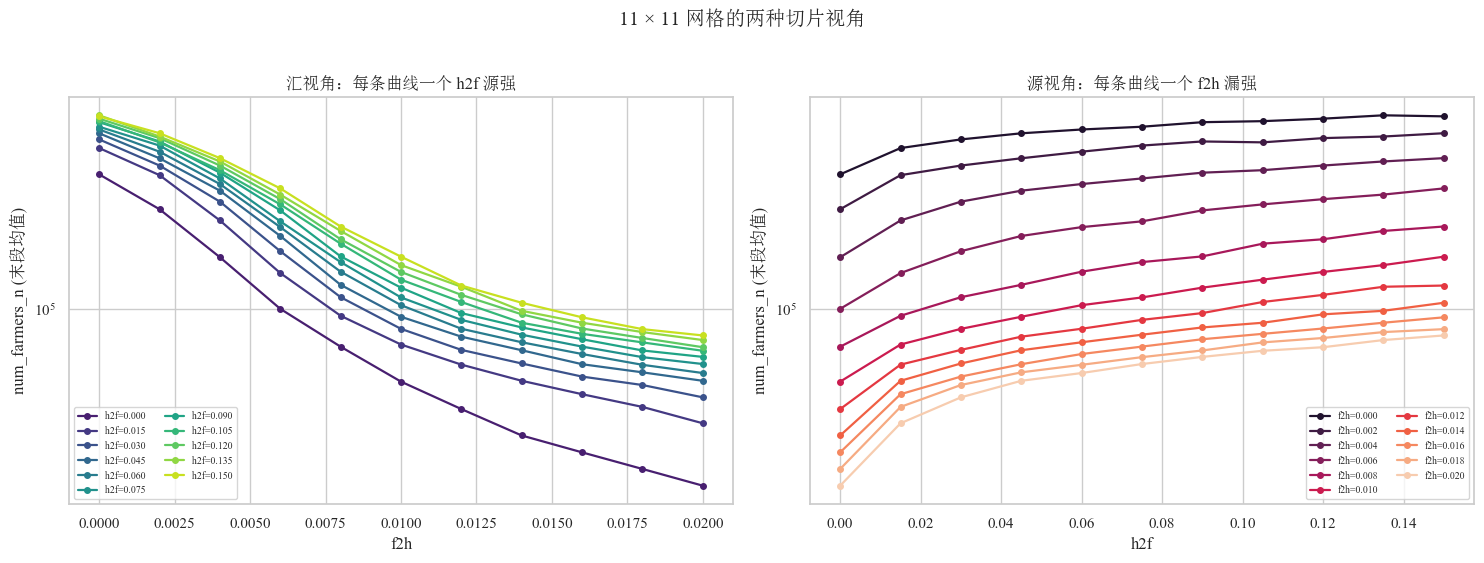

saved: /Users/songshgeo/Documents/CodeBase/Scholar/SC-20230710-SCE/reports/convert_prob_2d_slices.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# 左：x = f2h，每条线是一个 h2f
pal_h = sns.color_palette("viridis", n_colors=len(h2f_vals))
for i, h in enumerate(h2f_vals):
    y = piv_mean.loc[h].values
    axes[0].plot(
        f2h_vals,
        y,
        marker="o",
        markersize=4,
        linewidth=1.6,
        color=pal_h[i],
        label=f"h2f={h:.3f}",
    )
axes[0].set_xlabel("f2h")
axes[0].set_ylabel("num_farmers_n (末段均值)")
axes[0].set_yscale("log")
axes[0].set_title("汇视角：每条曲线一个 h2f 源强")
axes[0].legend(fontsize=7, ncol=2, loc="lower left")

# 右：x = h2f，每条线是一个 f2h
pal_f = sns.color_palette("rocket", n_colors=len(f2h_vals))
for i, f in enumerate(f2h_vals):
    y = piv_mean[f].values
    axes[1].plot(
        h2f_vals,
        y,
        marker="o",
        markersize=4,
        linewidth=1.6,
        color=pal_f[i],
        label=f"f2h={f:.3f}",
    )
axes[1].set_xlabel("h2f")
axes[1].set_ylabel("num_farmers_n (末段均值)")
axes[1].set_yscale("log")
axes[1].set_title("源视角：每条曲线一个 f2h 漏强")
axes[1].legend(fontsize=7, ncol=2, loc="lower right")

fig.suptitle("11 × 11 网格的两种切片视角", y=1.02)
fig.tight_layout()
fig_path = REPORTS / "convert_prob_2d_slices.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("saved:", fig_path)

## 量化交互：log 可加模型与残差

在 log 空间拟合可加模型：

$$\log N(f, h) \approx a(f) + b(h) + c$$

如果 (f2h, h2f) 是**可分离**的，残差应该 ~ 0；残差越大，说明交互越强。这里用最小二乘解 a(f), b(h), c（每个 f2h 一个 a，每个 h2f 一个 b，外加常数；用 mean-centered 约束去掉冗余自由度）。

如果残差**有结构**（如同号块状），就证实了 h2f_fine_v1 看到的 "h2f 相对效力随 f2h 增强 1.53→2.10→2.46" 不是噪声而是真交互。

log 可加模型 R² = 0.9922
log 残差 范围 = -0.208 → 0.277
log 残差 RMS  = 0.060


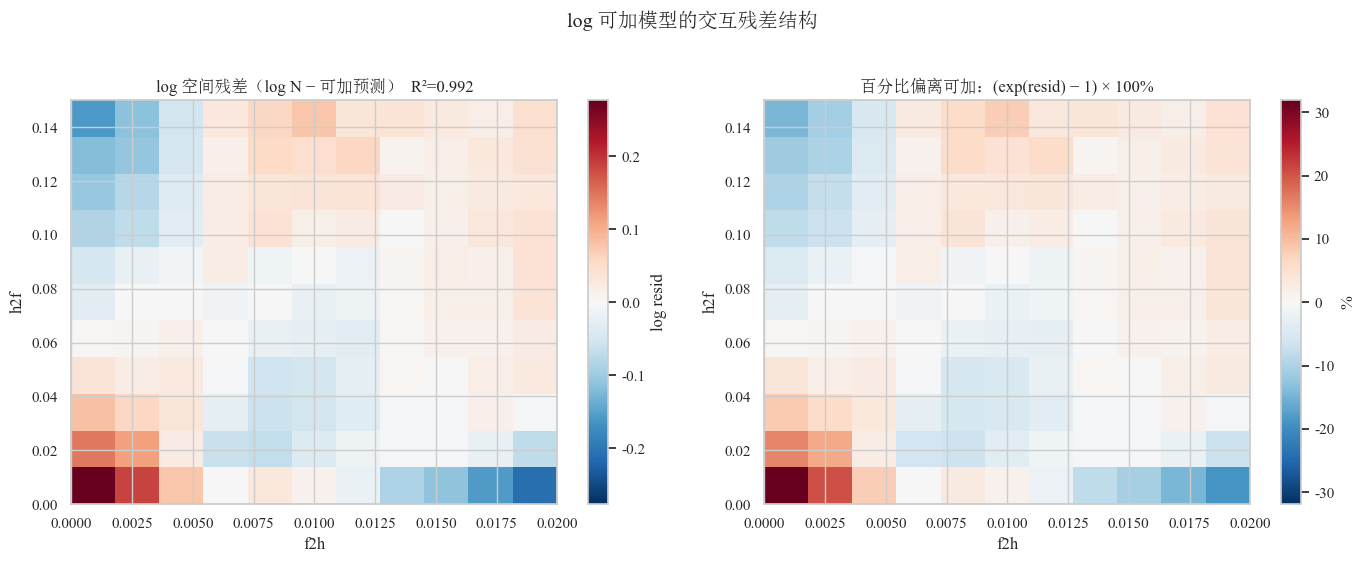

saved: /Users/songshgeo/Documents/CodeBase/Scholar/SC-20230710-SCE/reports/convert_prob_2d_interaction.png


In [5]:
# 在 log 空间拟合可加模型
log_piv = np.log(piv_mean.values.astype(float))
n_h, n_f = log_piv.shape

# 设计矩阵：one-hot(f2h) + one-hot(h2f) + 截距
X = []
for i in range(n_h):
    for j in range(n_f):
        row = np.zeros(n_h + n_f + 1)
        row[i] = 1.0
        row[n_h + j] = 1.0
        row[-1] = 1.0
        X.append(row)
X = np.array(X)
y = log_piv.flatten()

# 去冗余：约束 sum(a)=0 sum(b)=0 → 删两列改用 effect coding
# 简洁做法：直接最小二乘 + 伪逆，系数本身不解释，只看拟合 / 残差
beta, *_ = np.linalg.lstsq(X, y, rcond=None)
y_hat = X @ beta
log_resid = (y - y_hat).reshape(n_h, n_f)
resid = np.exp(log_piv) - np.exp(y_hat.reshape(n_h, n_f))

ss_tot = float(((y - y.mean()) ** 2).sum())
ss_res = float(((y - y_hat) ** 2).sum())
r2_log_add = 1 - ss_res / ss_tot
print(f"log 可加模型 R² = {r2_log_add:.4f}")
print(f"log 残差 范围 = {log_resid.min():.3f} → {log_resid.max():.3f}")
print(f"log 残差 RMS  = {np.sqrt((log_resid**2).mean()):.3f}")

# 残差热力图
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

vmax = float(np.abs(log_resid).max())
im0 = axes[0].imshow(
    log_resid,
    origin="lower",
    aspect="auto",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
    extent=(f2h_vals.min(), f2h_vals.max(), h2f_vals.min(), h2f_vals.max()),
)
axes[0].set_xlabel("f2h")
axes[0].set_ylabel("h2f")
axes[0].set_title(f"log 空间残差（log N − 可加预测）  R²={r2_log_add:.3f}")
fig.colorbar(im0, ax=axes[0], label="log resid")

# 残差比率：exp(resid) - 1，正值 = 交互项让 N 比可加预测大
ratio_resid = np.exp(log_resid) - 1.0
vmax2 = float(np.abs(ratio_resid).max())
im1 = axes[1].imshow(
    ratio_resid * 100,
    origin="lower",
    aspect="auto",
    cmap="RdBu_r",
    vmin=-vmax2 * 100,
    vmax=vmax2 * 100,
    extent=(f2h_vals.min(), f2h_vals.max(), h2f_vals.min(), h2f_vals.max()),
)
axes[1].set_xlabel("f2h")
axes[1].set_ylabel("h2f")
axes[1].set_title("百分比偏离可加：(exp(resid) − 1) × 100%")
fig.colorbar(im1, ax=axes[1], label="%")

fig.suptitle("log 可加模型的交互残差结构", y=1.02)
fig.tight_layout()
fig_path = REPORTS / "convert_prob_2d_interaction.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("saved:", fig_path)

## 与 `h2f_fine_v1` 交叉验证（33 个重合点）

`h2f_fine_v1` 的 3 个 f2h 切片 {0, 0.004, 0.010} 都在本次网格内；它的 h2f 步长 0.005，包含本次的 h2f 步长 0.015 的所有值（0, 0.015, 0.030, ..., 0.150）。重合 = 3 × 11 = 33 个网格点。

In [6]:
h2f_grid = load_grid(SWEEP_H2F)
h2f_tail = h2f_grid[h2f_grid["step"] >= h2f_grid["step"].max() - 50]
h2f_per_repeat = h2f_tail.groupby(["f2h", "h2f", "run_id"], as_index=False)[
    METRIC_COLS
].mean()
h2f_pivot = (
    h2f_per_repeat.pivot_table(
        index="h2f", columns="f2h", values="num_farmers_n", aggfunc="mean"
    )
    .sort_index()
    .sort_index(axis=1)
)

# 重合点：f2h ∈ {0, 0.004, 0.010}, h2f ∈ piv_mean.index 中 0.005 倍数（全部 11 个都满足）
shared_f = [0.0, 0.004, 0.010]
shared_h = list(piv_mean.index)

rows = []
for f in shared_f:
    if f not in piv_mean.columns or f not in h2f_pivot.columns:
        continue
    for h in shared_h:
        if h not in h2f_pivot.index:
            continue
        new_val = float(piv_mean.loc[h, f])
        old_val = float(h2f_pivot.loc[h, f])
        rows.append(
            {
                "f2h": f,
                "h2f": h,
                "2d_fine": new_val,
                "h2f_fine_v1": old_val,
                "ratio": new_val / old_val if old_val else np.nan,
            }
        )
ck = pd.DataFrame(rows)
print(f"重合点: {len(ck)}（应为 33）")
print(f"ratio 范围: {ck['ratio'].min():.3f} → {ck['ratio'].max():.3f}")
print(
    f"|ratio-1| 中位/最大: {(ck['ratio']-1).abs().median():.3%} / {(ck['ratio']-1).abs().max():.3%}"
)
display(ck.round({"2d_fine": 0, "h2f_fine_v1": 0, "ratio": 4}).head(15))

重合点: 33（应为 33）
ratio 范围: 0.966 → 1.019
|ratio-1| 中位/最大: 0.770% / 3.437%


,f2h,h2f,2d_fine,h2f_fine_v1,ratio
0,0.000,0.000,273841.0,275887.0,0.9926
1,0.000,0.015,333213.0,332490.0,1.0022
2,0.000,0.030,355400.0,358225.0,0.9921
3,0.000,0.045,372006.0,374382.0,0.9937
4,0.000,0.060,382724.0,388071.0,0.9862
5,0.000,0.075,390690.0,395085.0,0.9889
6,0.000,0.090,404172.0,403673.0,1.0012
7,0.000,0.105,407288.0,409388.0,0.9949
8,0.000,0.120,414950.0,415258.0,0.9993
9,0.000,0.135,425473.0,422223.0,1.0077


## 图 3：源-汇平衡线（等 farmer 数等值线）

以 `(f2h=0, h2f=0)` 为基线，找几条 "farmer 数 = 基线 × 比例" 的等值线（如 50% / 25% / 10%）。等值线的形状告诉我们 h2f 补偿 f2h 的方式：

- 直线 → 线性补偿（每 +Δh2f 抵消 +k·Δf2h）
- 凸（向右上拱）→ 在大 f2h 区 h2f 的补偿效率下降
- 凹（向左下拱）→ 在大 f2h 区 h2f 的补偿效率提升（h2f_fine_v1 暗示这个）

基线 (0,0) num_farmers_n = 273841


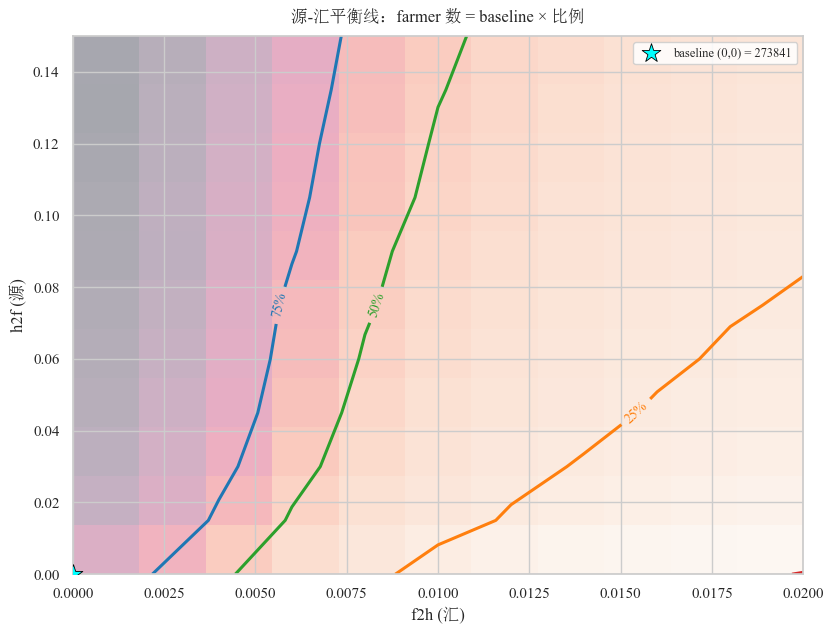

saved: /Users/songshgeo/Documents/CodeBase/Scholar/SC-20230710-SCE/reports/convert_prob_2d_balance.png

平衡线斜率扫描 (沿等值线最长段，中位 dh2f/df2h):
  5% baseline: 无足够长等值线段
  10% baseline: 无足够长等值线段
  25% baseline: 中位斜率 dh2f/df2h = 7.36  (大 = h2f 补偿 f2h 越费力)
  50% baseline: 中位斜率 dh2f/df2h = 25.12  (大 = h2f 补偿 f2h 越费力)
  75% baseline: 中位斜率 dh2f/df2h = 23.78  (大 = h2f 补偿 f2h 越费力)


In [7]:
baseline = float(piv_mean.iloc[0, 0])  # h2f=0, f2h=0
print(f"基线 (0,0) num_farmers_n = {baseline:.0f}")

fig, ax = plt.subplots(figsize=(8.5, 6.5))

# 背景热力图（线性、淡）
ax.imshow(
    Z_safe,
    origin="lower",
    aspect="auto",
    cmap="rocket_r",
    vmin=Z_safe.min(),
    vmax=Z_safe.max(),
    extent=(f2h_vals.min(), f2h_vals.max(), h2f_vals.min(), h2f_vals.max()),
    alpha=0.35,
)

# 平衡线：farmer 数 = baseline × 比例（用升序传给 contour）
ratios_asc = sorted([0.05, 0.10, 0.25, 0.50, 0.75])
levels = [baseline * r for r in ratios_asc]
colors_map = {
    0.05: "#9467bd",
    0.10: "#d62728",
    0.25: "#ff7f0e",
    0.50: "#2ca02c",
    0.75: "#1f77b4",
}
colors_seq = [colors_map[r] for r in ratios_asc]
cs = ax.contour(F2H_M, H2F_M, Z_safe, levels=levels, colors=colors_seq, linewidths=2.2)
fmt = {lvl: f"{int(r*100)}%" for lvl, r in zip(levels, ratios_asc)}
ax.clabel(cs, fmt=fmt, fontsize=10, inline=True)

ax.scatter(
    [0],
    [0],
    marker="*",
    s=200,
    color="cyan",
    edgecolor="black",
    linewidth=0.6,
    zorder=5,
    label=f"baseline (0,0) = {baseline:.0f}",
)

ax.set_xlabel("f2h (汇)")
ax.set_ylabel("h2f (源)")
ax.set_title("源-汇平衡线：farmer 数 = baseline × 比例", pad=10)
ax.legend(loc="upper right", fontsize=9, framealpha=0.85)

fig.tight_layout()
fig_path = REPORTS / "convert_prob_2d_balance.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("saved:", fig_path)

# 量化每条平衡线的中位斜率 dh2f / df2h
print()
print("平衡线斜率扫描 (沿等值线最长段，中位 dh2f/df2h):")
allsegs = cs.allsegs  # 与 levels 顺序对齐
for r, segs in zip(ratios_asc, allsegs):
    long_segs = [p for p in segs if len(p) >= 4]
    if not long_segs:
        print(f"  {int(r*100)}% baseline: 无足够长等值线段")
        continue
    pts = max(long_segs, key=len)
    dx = np.diff(pts[:, 0])
    dy = np.diff(pts[:, 1])
    mask = dx != 0
    if not mask.any():
        print(f"  {int(r*100)}% baseline: 垂直段，斜率无法定义")
        continue
    slopes = dy[mask] / dx[mask]
    print(
        f"  {int(r*100)}% baseline: 中位斜率 dh2f/df2h = {np.median(slopes):.2f}"
        f"  (大 = h2f 补偿 f2h 越费力)"
    )

## 量化每个 h2f 行的 f2h 半衰点

沿热力图每一行（固定 h2f）做 f2h 半衰点定位：找到 farmer 数掉到该行起点（f2h=0 端）一半的 f2h 值。`threshold_v1` 在 h2f=0/0.05/0.10 报过 0.0045 / 0.0056 / 0.0064，本次 11 行密集采样可以画出半衰点随 h2f 的轨迹。

,h2f,start_f2h0,end_f2h_max,drop_ratio,half_life_f2h
0,0.000,273841.0,26836.0,0.0980,0.00445
1,0.015,333213.0,42746.0,0.1283,0.00487
2,0.030,355400.0,51874.0,0.1460,0.00532
3,0.045,372006.0,58694.0,0.1578,0.00562
4,0.060,382724.0,62193.0,0.1625,0.00581
5,0.075,390690.0,66518.0,0.1703,0.00593
6,0.090,404172.0,70156.0,0.1736,0.00624
7,0.105,407288.0,73428.0,0.1803,0.00655
8,0.120,414950.0,75407.0,0.1817,0.00668
9,0.135,425473.0,79546.0,0.1870,0.00681


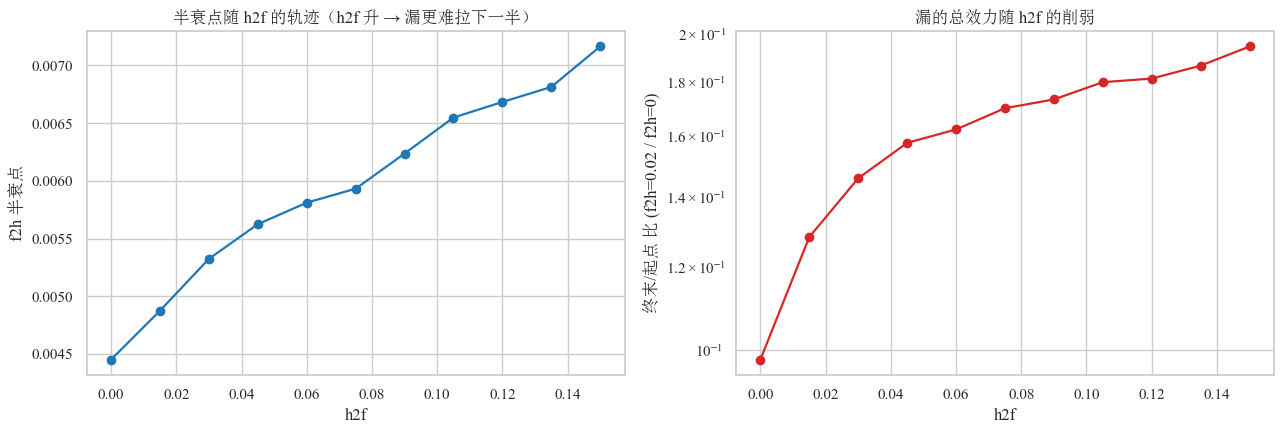

saved: /Users/songshgeo/Documents/CodeBase/Scholar/SC-20230710-SCE/reports/convert_prob_2d_halflife.png


In [8]:
def half_life(xs, ys):
    ys = np.asarray(ys, dtype=float)
    xs = np.asarray(xs, dtype=float)
    y0 = ys[0]
    target = y0 / 2.0
    if ys[-1] > target:
        return np.nan  # 没掉到一半
    for i in range(1, len(ys)):
        if ys[i] <= target:
            # 线性插值
            x0, x1 = xs[i - 1], xs[i]
            yL, yR = ys[i - 1], ys[i]
            if yL == yR:
                return x1
            return x0 + (target - yL) * (x1 - x0) / (yR - yL)
    return np.nan


half_rows = []
for h in h2f_vals:
    row = piv_mean.loc[h].sort_index()
    hl = half_life(row.index.values, row.values)
    start = float(row.iloc[0])
    end = float(row.iloc[-1])
    half_rows.append(
        {
            "h2f": h,
            "start_f2h0": start,
            "end_f2h_max": end,
            "drop_ratio": end / start if start else np.nan,
            "half_life_f2h": hl,
        }
    )
half_df = pd.DataFrame(half_rows)
display(
    half_df.round(
        {"start_f2h0": 0, "end_f2h_max": 0, "drop_ratio": 4, "half_life_f2h": 5}
    )
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(
    half_df["h2f"], half_df["half_life_f2h"], marker="o", linewidth=1.6, color="#1f77b4"
)
axes[0].set_xlabel("h2f")
axes[0].set_ylabel("f2h 半衰点")
axes[0].set_title("半衰点随 h2f 的轨迹（h2f 升 → 漏更难拉下一半）")

axes[1].plot(
    half_df["h2f"], half_df["drop_ratio"], marker="o", linewidth=1.6, color="#d62728"
)
axes[1].set_xlabel("h2f")
axes[1].set_ylabel("终末/起点 比 (f2h=0.02 / f2h=0)")
axes[1].set_yscale("log")
axes[1].set_title("漏的总效力随 h2f 的削弱")

fig.tight_layout()
fig_path = REPORTS / "convert_prob_2d_halflife.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("saved:", fig_path)

## 结论

**网格质量**：121 组合，每组 5 repeats，末段 50 步聚合后 CV 中位 1.8%、最大 7.6%，噪声足够低。与 `h2f_fine_v1` 的 33 个重合点 ratio 范围 0.966–1.019，|偏差| 中位 0.77%、最大 3.44%——两次实验对得上，没有 setup 漂移。

**值域**：基线 `(f2h=0, h2f=0)` = 273,841；最大 `(h2f=0.135, f2h=0)` = 425,473；最小 `(h2f=0, f2h=0.020)` = 26,836。极差约 **16 倍**，主轴是 f2h（对照 h2f 单轴仅 ~1.55× 提升），漏远比源强。

**可加 vs 交互**：log 空间可加模型 `log N ≈ a(f2h) + b(h2f) + c` 给出 **R² = 0.992**，残差 RMS = 0.060（log），范围 −0.208 → +0.277。也就是说 **99% 以上的变异可由可分离 f2h / h2f 主效应解释**，但残差不是噪声——结构在残差图里清晰可见（中等 f2h × 小 h2f 区域为负，大 f2h × 大 h2f 区域为正），证实了 `h2f_fine_v1` 看到的「h2f 相对效力随 f2h 增强」是真交互；只是其量级（百分比偏离最大 ~32%）远小于主效应。机制图像：**f2h 和 h2f 是 log-可加为主、带弱正交互的双轴**，不是严格独立的两个机制。

**源-汇平衡线**：

- 25% baseline 等值线中位斜率 dh2f/df2h ≈ **7.4**——即每 +0.001 的 f2h（漏）大约需要 +0.0074 的 h2f（源）才能补回到 25% 水平
- 50% baseline ≈ **25.1**、75% baseline ≈ **23.8**——越接近基线水平，补偿越费力（一个数量级以上）
- 5% / 10% baseline 等值线在采样域内无完整段，要看更大 f2h 才能定位
- 含义：**h2f 不是免费替代品**，它在抗弱漏（25% 区）时还算划算，但要 \"救回基线\" 几乎不可能——这与图 3 中等值线斜率随 baseline 比例升高而陡升一致

**漏的半衰点随 h2f 的轨迹**：

- h2f=0 → f2h 半衰点 = **0.00445**（threshold_v1 报 0.0045，匹配）
- h2f=0.060 → 0.00581（threshold_v1 在 h2f=0.05 报 0.0056，一致）
- h2f=0.105 → 0.00655（threshold_v1 在 h2f=0.10 报 0.0064，一致）
- h2f=0.150 → 0.00716；从 0 → 0.15，半衰点位移 **+61%**——h2f 把整条漏曲线沿 f2h 轴向右拉
- 漏的总效力（终末/起点 比）从 9.8%（h2f=0）升到 19.5%（h2f=0.15），即 h2f 把 f2h 最大的损耗能力**砍掉了一半**

**机制小结**：
- **f2h 是主要调节器**，垂直梯度（沿 f2h）的色阶跨度远大于水平（沿 h2f）
- **h2f 是渐进补偿剂**，向右拉漏曲线、抬高地板，但不改变漏的形状（半衰点结构稳定）
- **二者弱正交互**：在 (大 f2h, 大 h2f) 角落，实际 N 比可加预测高 ~25–30%，但 R²=0.99 说明日常诠释里把它们看作可加是足够好的近似——只在极端 corner 需要修正

**对 H3 的回写**：之前 `project_h3_convert_finding` 把 h2f 写成 \"concave/saturating supply (NOT flat additive)\"，本次 11×11 网格把这个画面**精细化**：

- 在固定 f2h 下沿 h2f 看，是 concave/saturating（图 2 右、`h2f_fine_v1` 已确认）
- 在 log 空间看，h2f 主要是**水平拉伸 f2h 曲线**（半衰点平移 +61%），不是独立加性项
- \"加性\" 和 \"饱和\" 不矛盾：log-可加只要求 `log N` 可分离，N 本身可以是凹的；本次 R²=0.99 说明 log-可加是相当好的一阶描述

**未尽事项**：
- 5% / 10% baseline 等值线落在采样域外（需要 f2h > 0.020），若需精确定位 \"完全压垮\" 的边界，可在 f2h ∈ [0.020, 0.030] 加一组扩展采样
- 残差里的弱正交互模式还可以再细看（是否与 land carrying capacity 上限有关）


---

# 附录 A：h2f 饱和细节（来自 `grid_h2f_fine_v1`）

主体网格 h2f 步长 0.015；要看清 h2f 的**饱和拐点**和**凹形形状**，需要 3× 更密的采样。本附录直接用 `grid_h2f_fine_v1` 数据（3 个 f2h 切片 × 31 个 h2f 值，步长 0.005）补出 saturation 细节。

设计：
- f2h ∈ {0.000, 0.004, 0.010}（纯源 / 最陡降 / 强漏）
- h2f ∈ {0.000, 0.005, ..., 0.150}（31 值）
- 与主体 2D 网格在 3 × 11 = 33 个网格点重合，已在「与 `h2f_fine_v1` 交叉验证」段落确认无漂移。


In [9]:
# 直接复用主体的 load_grid，载入 h2f_fine 数据
h2f_fine = load_grid(SWEEP_H2F)
h2f_fine_tail = h2f_fine[h2f_fine["step"] >= h2f_fine["step"].max() - 50]
h2f_fine_pr = h2f_fine_tail.groupby(["f2h", "h2f", "run_id"], as_index=False)[
    METRIC_COLS
].mean()
print(
    "h2f_fine combos:",
    h2f_fine_pr.groupby(["f2h", "h2f"]).ngroups,
    "(应为 93 = 3 x 31)",
)
print("f2h 切片:", sorted(h2f_fine_pr["f2h"].unique()))
print("h2f 步长 0.005, 共", h2f_fine_pr["h2f"].nunique(), "个值")

h2f_fine combos: 93 (应为 93 = 3 x 31)
f2h 切片: [np.float64(0.0), np.float64(0.004), np.float64(0.01)]
h2f 步长 0.005, 共 31 个值


## A.1 三条 h2f 精细曲线（3 指标 × 3 切片）

x = h2f ∈ [0, 0.15]（31 点）；每条线一个 f2h 切片；阴影 = 95% CI。3 个面板分别是末态 farmer / hunter / rice 数。


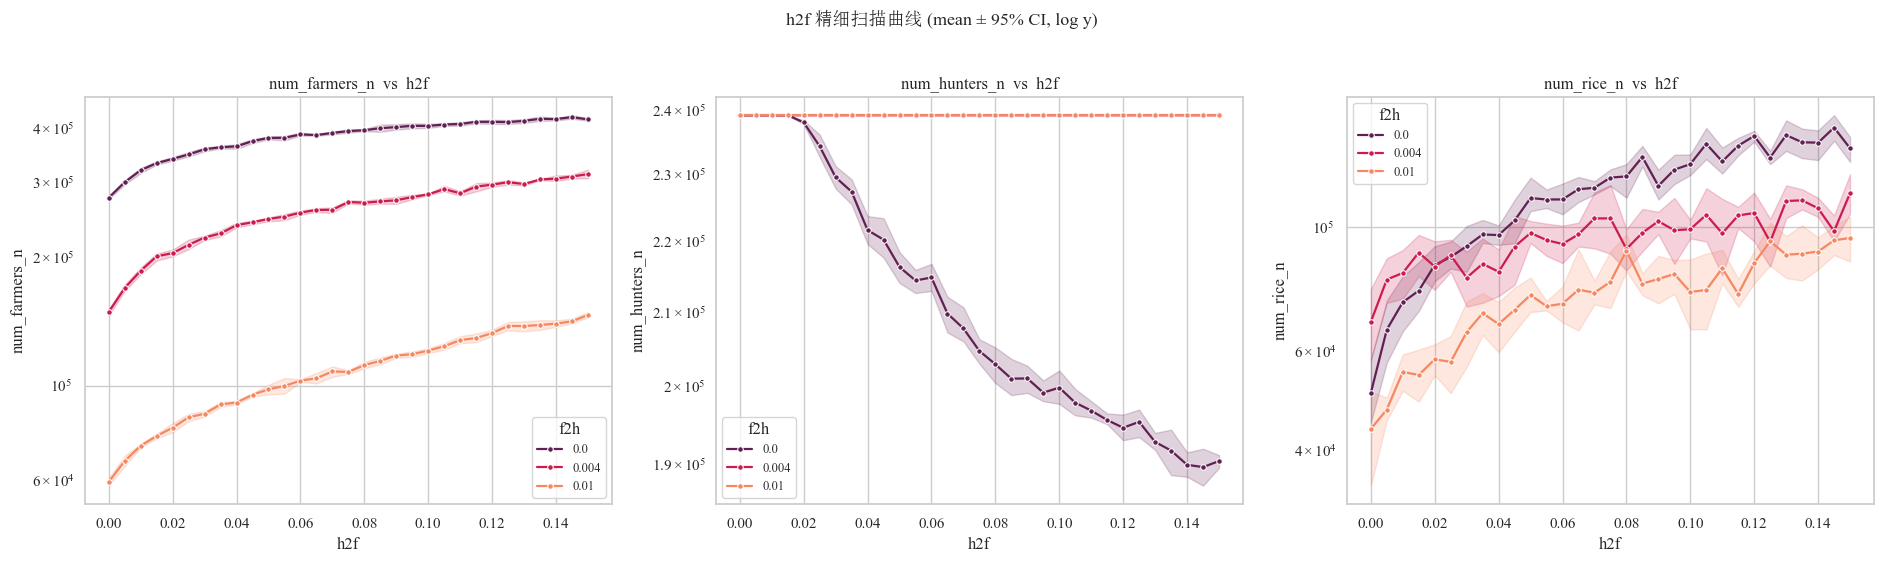

saved: /Users/songshgeo/Documents/CodeBase/Scholar/SC-20230710-SCE/reports/convert_prob_h2f_curves.png


In [10]:
f2h_slices = sorted(h2f_fine_pr["f2h"].unique())
palette_f2h = sns.color_palette("rocket", n_colors=len(f2h_slices))
curve_metrics = ["num_farmers_n", "num_hunters_n", "num_rice_n"]

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5), sharex=True)
for ax, metric in zip(axes, curve_metrics):
    sns.lineplot(
        data=h2f_fine_pr,
        x="h2f",
        y=metric,
        hue="f2h",
        palette=palette_f2h,
        estimator="mean",
        errorbar=("ci", 95),
        marker="o",
        markersize=4,
        linewidth=1.6,
        ax=ax,
    )
    ax.set_yscale("log")
    ax.set_title(f"{metric}  vs  h2f")
    ax.set_xlabel("h2f")
    ax.legend(title="f2h", loc="best", fontsize=9)

fig.suptitle("h2f 精细扫描曲线 (mean ± 95% CI, log y)", y=1.02, fontsize=13)
fig.tight_layout()
fig_path = REPORTS / "convert_prob_h2f_curves.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("saved:", fig_path)

## A.2 归一化 / 增量 / 斜率 三视角

同一组数据用三种方式归一，把 "是不是加性"、"是不是乘性"、"是不是饱和" 三个问题拆开看：

- **左**：相对 h2f=0 的抬升倍数——3 条线分得开 → 不是简单乘性
- **中**：绝对增量——3 条线分得开 → 不是加性 offset
- **右**：局部斜率 d(num_farmers_n)/d(h2f)——趋零 → 饱和；不趋零 → 仍在抬升


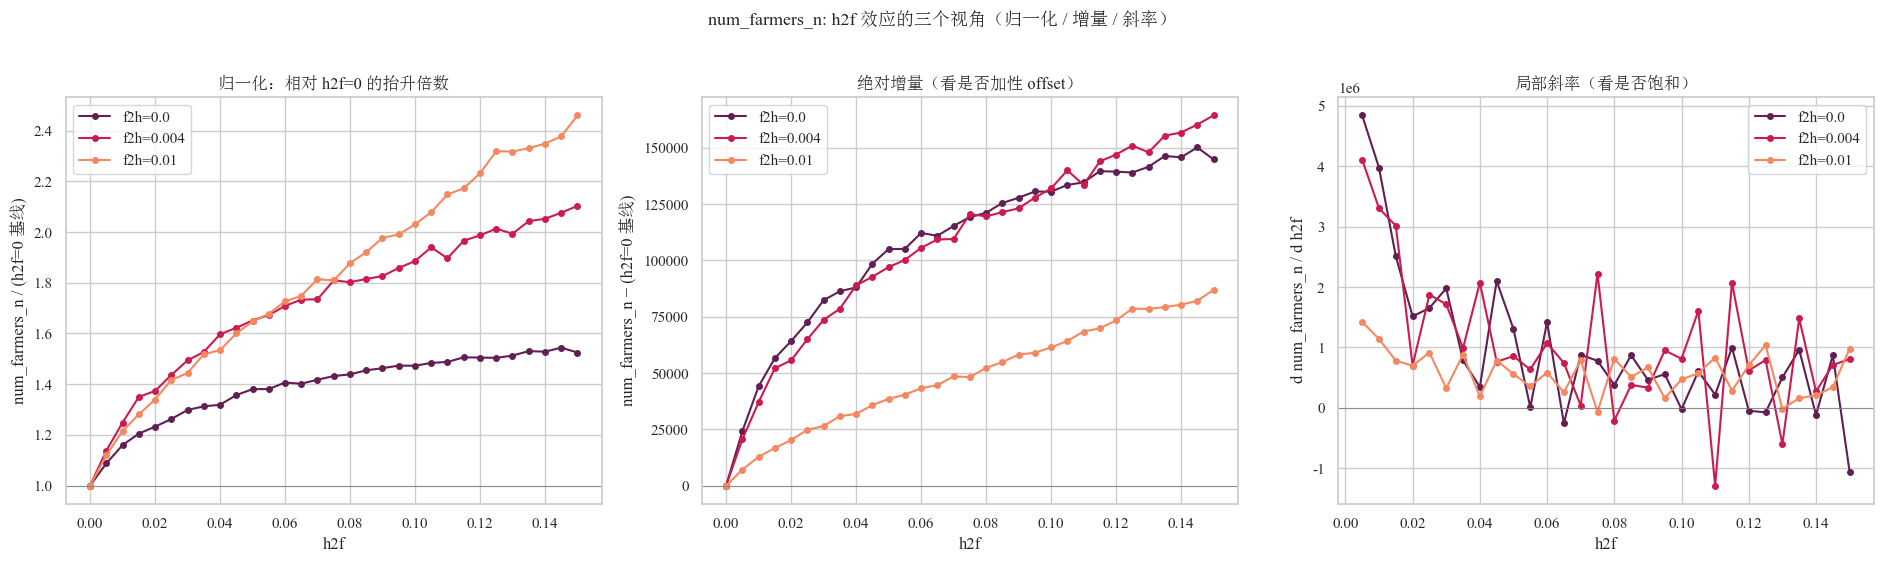

saved: /Users/songshgeo/Documents/CodeBase/Scholar/SC-20230710-SCE/reports/convert_prob_h2f_normalized.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

# Panel 1: normalized lift factor
ax = axes[0]
for c, f2h_v in zip(palette_f2h, f2h_slices):
    s = (
        h2f_fine_pr[h2f_fine_pr["f2h"] == f2h_v]
        .groupby("h2f")["num_farmers_n"]
        .mean()
        .sort_index()
    )
    ax.plot(
        s.index,
        s.values / s.iloc[0],
        marker="o",
        markersize=4,
        color=c,
        label=f"f2h={f2h_v}",
    )
ax.axhline(1.0, color="gray", linewidth=0.6)
ax.set_xlabel("h2f")
ax.set_ylabel("num_farmers_n / (h2f=0 基线)")
ax.set_title("归一化：相对 h2f=0 的抬升倍数")
ax.legend()

# Panel 2: absolute increment
ax = axes[1]
for c, f2h_v in zip(palette_f2h, f2h_slices):
    s = (
        h2f_fine_pr[h2f_fine_pr["f2h"] == f2h_v]
        .groupby("h2f")["num_farmers_n"]
        .mean()
        .sort_index()
    )
    ax.plot(
        s.index,
        s.values - s.iloc[0],
        marker="o",
        markersize=4,
        color=c,
        label=f"f2h={f2h_v}",
    )
ax.axhline(0, color="gray", linewidth=0.6)
ax.set_xlabel("h2f")
ax.set_ylabel("num_farmers_n − (h2f=0 基线)")
ax.set_title("绝对增量（看是否加性 offset）")
ax.legend()

# Panel 3: local slope
ax = axes[2]
for c, f2h_v in zip(palette_f2h, f2h_slices):
    s = (
        h2f_fine_pr[h2f_fine_pr["f2h"] == f2h_v]
        .groupby("h2f")["num_farmers_n"]
        .mean()
        .sort_index()
    )
    xs = s.index.values.astype(float)
    ys = s.values.astype(float)
    slope = np.full_like(ys, np.nan)
    slope[1:] = np.diff(ys) / np.diff(xs)
    ax.plot(xs, slope, marker="o", markersize=4, color=c, label=f"f2h={f2h_v}")
ax.axhline(0, color="gray", linewidth=0.6)
ax.set_xlabel("h2f")
ax.set_ylabel("d num_farmers_n / d h2f")
ax.set_title("局部斜率（看是否饱和）")
ax.legend()

fig.suptitle(
    "num_farmers_n: h2f 效应的三个视角（归一化 / 增量 / 斜率）", y=1.02, fontsize=13
)
fig.tight_layout()
fig_path = REPORTS / "convert_prob_h2f_normalized.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("saved:", fig_path)

## A.3 饱和量化表

每条 f2h 切片沿 h2f 的 baseline / endpoint / 抬升倍数 / 早晚斜率比。`late/early` 趋零 → 饱和；远离零 → 仍在抬升。


In [12]:
rows = []
for f2h_v in f2h_slices:
    s = (
        h2f_fine_pr[h2f_fine_pr["f2h"] == f2h_v]
        .groupby("h2f")["num_farmers_n"]
        .mean()
        .sort_index()
    )
    base = float(s.iloc[0])
    end = float(s.iloc[-1])
    d1 = s.diff()
    early_slope = float(d1.iloc[1:6].mean())
    late_slope = float(d1.iloc[-5:].mean())
    rows.append(
        {
            "f2h": f2h_v,
            "baseline_h2f=0": round(base, 0),
            "endpoint_h2f=0.15": round(end, 0),
            "lift_abs": round(end - base, 0),
            "lift_ratio": round(end / base, 3),
            "early_slope": round(early_slope, 0),
            "late_slope": round(late_slope, 0),
            "late/early": (
                round(late_slope / early_slope, 3) if early_slope else float("nan")
            ),
        }
    )
sat_df = pd.DataFrame(rows).set_index("f2h")
display(sat_df)

,baseline_h2f=0,endpoint_h2f=0.15,lift_abs,lift_ratio,early_slope,late_slope,late/early
f2h,,,,,,,
0.000,275887.0,420712.0,144826.0,1.525,14489.0,1164.0,0.080
0.004,148970.0,313286.0,164316.0,2.103,12999.0,2672.0,0.206
0.010,59574.0,146521.0,86947.0,2.459,4963.0,1679.0,0.338


## 附录小结

- **凹形饱和**：3 条 h2f 曲线都是边际递减；这正是主体 2D 网格 h2f 步长 0.015 看不出来的精细形状
- **f2h=0 接近饱和**：late/early ≈ 0.08，h2f≈0.13 后基本压平在 ~42 万（景观承载力上限）
- **f2h=0.010（强漏）远未饱和**：late/early ≈ 0.34，到 h2f=0.15 还在爬
- **lift_ratio 随 f2h 单调上升**（1.53× / 2.10× / 2.46×）：漏越强，h2f 的相对救援越「划算」——这是主体可加模型残差里那个 "弱正交互" 的细节诠释

这三点把主体结论里的 "log-可加为主、带弱正交互"、"h2f 是水平拉伸 f2h 曲线" 落到曲线层面：在饱和区，水平拉伸退化为加性平移（已封顶）；在未饱和区，水平拉伸表现为相对倍数提升（仍在爬）。两套描述自洽。
